In [7]:
import pystormtracker as pst
import numba
import numpy as np
import xarray as xr

import sys
import os

import matplotlib.pyplot as plt
import matplotlib
from tqdm import tqdm
import seaborn as sns
from scipy import stats
import cmocean
import pandas as pd
import cartopy.crs as ccrs
from matplotlib.colors import TwoSlopeNorm


In [8]:
ds = xr.open_dataset("/Users/asgerthormann/Documents/uni/master/master_code/master_thesis/data/single_levels_6h/data_stream-oper_stepType-instant.nc")

In [9]:
ds

<xarray.Dataset> Size: 1GB
Dimensions:     (valid_time: 244, latitude: 281, longitude: 601)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 1999-11-01 ... 1999-12-31T18:...
    expver      (valid_time) <U4 4kB ...
  * latitude    (latitude) float64 2kB 90.0 89.75 89.5 89.25 ... 20.5 20.25 20.0
  * longitude   (longitude) float64 5kB -90.0 -89.75 -89.5 ... 59.5 59.75 60.0
    number      int64 8B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 165MB ...
    v10         (valid_time, latitude, longitude) float32 165MB ...
    d2m         (valid_time, latitude, longitude) float32 165MB ...
    t2m         (valid_time, latitude, longitude) float32 165MB ...
    msl         (valid_time, latitude, longitude) float32 165MB ...
    sst         (valid_time, latitude, longitude) float32 165MB ...
    sp          (valid_time, latitude, longitude) float32 165MB ...
    i10fg       (valid_time, latitude, longitude) float32 165MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-02T14:48 GRIB to CDM+CF via cfgrib-0.9.1...

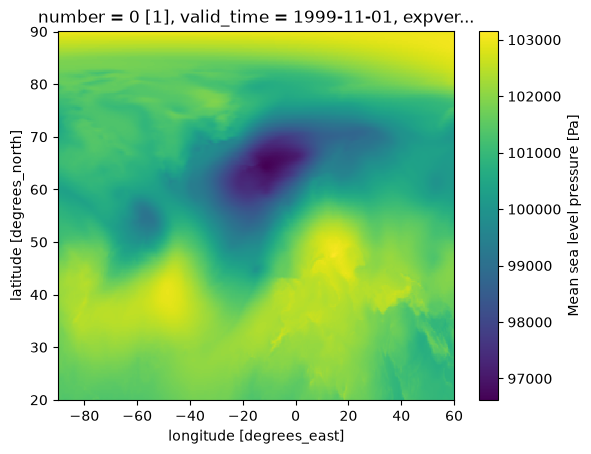

In [10]:
ds["msl"].isel(valid_time=0).plot()

In [11]:
tracker = pst.HodgesTracker()

In [12]:
tracker.track?

Signature:
tracker.track(
    data: 'TrackingInput',
    variable: 'str',
    *,
    start_time: 'TimeInput | None' = None,
    end_time: 'TimeInput | None' = None,
    time_step: 'np.timedelta64 | None' = None,
    detection_mode: 'DetectionMode' = 'auto',
    object_threshold: 'float | None' = None,
    engine: 'str | None' = None,
    **kwargs: 'object',
) -> 'Tracks'
Docstring: <no docstring>
File:      ~/mamba/envs/master_env/lib/python3.12/site-packages/pystormtracker/hodges/tracker.py
Type:      method

In [13]:
from pystormtracker.hodges import constants
print(vars(constants))


{'__name__': 'pystormtracker.hodges.constants', '__doc__': None, '__package__': 'pystormtracker.hodges', '__loader__': <_frozen_importlib_external.SourceFileLoader object at 0x17ea897f0>, '__spec__': ModuleSpec(name='pystormtracker.hodges.constants', loader=<_frozen_importlib_external.SourceFileLoader object at 0x17ea897f0>, origin='/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/pystormtracker/hodges/constants.py'), '__file__': '/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/pystormtracker/hodges/constants.py', '__cached__': '/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/pystormtracker/hodges/__pycache__/constants.cpython-312.pyc', '__builtins__': {'__name__': 'builtins', '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module i

In [14]:
INPUT_FILE = "/Users/asgerthormann/Documents/uni/master/master_code/master_thesis/data/single_levels_6h/data_stream-oper_stepType-instant.nc"       # your buffered NetCDF/GRIB subset
VARIABLE = "msl"               # or "vo" for 850 hPa relative vorticity
DETECTION_MODE = "min"         # "max" for vorticity

 

In [15]:
ds = xr.open_dataset(INPUT_FILE)
ds = ds.rename({"valid_time": "time"})   # only if needed
if "expver" in ds.dims:
    ds = ds.sel(expver=1)                 # pick final ERA5 (drop ERA5T), or combine_first

In [16]:
tracker = pst.HodgesTracker(
    min_track_points=8,
    taper_points=10,
    lmin=5,
    lmax=42
)
tracks = tracker.track(
    ds,
    VARIABLE,
    detection_mode=DETECTION_MODE,
)

In [17]:
for track in tracks:
    if len(track) >= 8:
        print(track.track_id, len(track))

1 244
3 244
4 8
5 244
7 244
8 8
9 244
10 10
11 244
13 244
14 10
15 244
16 11
17 244
18 26
19 244
21 244
23 244
24 33
25 244
26 38
27 244
29 244
31 244
32 9
33 244
34 17
35 244
36 17
37 244
39 244
40 18
41 244
42 244
44 244
46 244
48 244
50 244
51 244
52 244
53 244
54 100
55 244
56 244
57 244
58 244
59 244
60 244
61 244
62 244
63 244
64 244
65 244
66 244
67 244
68 244
69 244
70 244
71 244
72 50
73 48
74 244
75 244
76 244
77 53
78 244
79 244
80 244
81 244
82 244
83 244
84 45
85 17
87 18
88 244
89 244
92 19
93 244
94 244
96 63
97 22
98 62
99 64
100 103
101 244
102 244
103 244
104 244
105 244
106 244
107 244
108 244
109 244
111 244
112 39
113 244
114 132
115 244
116 133
117 21
118 244
119 22
120 244
121 244
122 13
123 244
124 244
125 98
129 48
133 8
143 15
144 31
149 26
150 39
152 16
153 20
154 20
158 21
160 22
161 11
164 185
167 17
168 12
171 107
174 107
175 24
176 107
193 24
195 15
198 21
199 33
202 11
203 10
204 10
205 39
208 31
211 12
212 18
214 244
215 244
216 244
217 244
218 120
219 

In [18]:
for track in tracks:
    if len(track) >= 8:
        print(
            track.track_id,
            "lon:", np.round(track.lons[:5], 2),
            "to", np.round(track.lons[-5:], 2),
            "lat:", np.round(track.lats[:5], 2),
            "to", np.round(track.lats[-5:], 2),
            "lat range:", np.nanmin(track.lats), np.nanmax(track.lats),
            "time span:", track.times[-1] - track.times[0]
        )


1 lon: [-90. -90. -90. -90. -90.] to [-90. -90. -90. -90. -90.] lat: [20. 20. 20. 20. 20.] to [20. 20. 20. 20. 20.] lat range: 20.0 20.0 time span: 5248800000
3 lon: [-79.75 -79.75 -79.75 -79.75 -79.75] to [-79.75 -79.75 -79.75 -79.75 -79.75] lat: [20. 20. 20. 20. 20.] to [20. 20. 20. 20. 20.] lat range: 20.0 20.0 time span: 5248800000
4 lon: [-36.29 -53.49 -62.04 -53.52 -45.1 ] to [-53.52 -45.1  -53.53 -45.14 -36.47] lat: [71.72 71.59 71.58 71.58 71.55] to [71.58 71.55 71.53 71.52 71.49] lat range: 71.49375313240145 71.72026350088949 time span: 151200000
5 lon: [-70.75 -70.75 -70.75 -70.75 -70.75] to [-70.75 -70.75 -70.75 -70.75 -70.75] lat: [20. 20. 20. 20. 20.] to [20. 20. 20. 20. 20.] lat range: 20.0 20.0 time span: 5248800000
7 lon: [-62.25 -62.25 -62.25 -62.25 -62.25] to [-62.25 -62.25 -62.25 -62.25 -62.25] lat: [20. 20. 20. 20. 20.] to [20. 20. 20. 20. 20.] lat range: 20.0 20.0 time span: 5248800000
8 lon: [-45.15 -53.55 -70.71 -70.73 -62.03] to [-70.73 -62.03 -53.44 -45.16 -28.

In [ ]:
tracks.write("tracks_msl_test.track", format='imilast')

In [20]:
with open("tracks_msl_test.txt", "r") as f:
    tracks_data = f.read()

In [ ]:
df_tracks = pd.read_csv("tracks_msl_test.txt", sep=" ", header=)

ParserError: Error tokenizing data. C error: Expected 3 fields in line 3, saw 12
